<div style="background-color:#EAEAEA;padding:20px;border-left:5px solid #6C757D;border-radius:6px;">
<table style="width:100%; border:none;"><tr style="border:none;">
<td style="border:none; vertical-align:top;">
<h1 style="font-size:32px; margin-top:0;">Master's Thesis</h1>
<hr style="margin:16px 0 22px 0;">
<p style="font-size:22px; line-height:1.5; margin:0;"><strong>Master's Degree in Advanced Physics</strong> - <strong>Universitat de Valencia</strong></p>
<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:</p>
<div style="font-size:25px;font-weight:700;line-height:1.3;margin-top:14px;margin-bottom:26px;">Fast Simulation of Neutrino Oscillations in Matter</div>
<p style="font-size:14px; line-height:1.55;"><strong>Author</strong><br>Juan Ramon Diaz Santos - <a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a></p>
<p style="font-size:14px; line-height:1.55;"><strong>Supervisors</strong><br>Roberto Ruiz de Austri Bazan - <a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>Michele Lucente - <a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a></p>
<p style="font-size:14px; line-height:1.55; margin-bottom:0;"><strong>Date</strong><br>September 2026</p></td>
<td style="border:none;width:230px;padding-left:25px;text-align:right;vertical-align:top;"><img src="../logo_uv.png" alt="Universitat de Valencia" style="width:200px; margin-top:5px;"></td>
</tr></table></div>

# Benchmark 5 — Runtime Context: Device, Precision and Method
---
This notebook benchmarks the same complete Standard Model physical workload, the incoherent \(^8\)B solar-neutrino mass weights propagated through the Earth to a fixed-depth detector, under three independent runtime and algorithmic choices: the execution device (CPU versus CUDA), the floating-point precision (`float32` versus `float64`), and the propagation method (the fast adiabatic/perturbative path versus the fully numerical path). Unlike `benchmark1_perturbative_vs_numerical.ipynb`, which scans four different physical pipelines at fixed device/dtype/method, this notebook fixes the physical pipeline and scans the `RuntimeContext` and method choices that a user selects when running it.

---

## Table of Contents

| # | Section |
|---|---|
| [0](#0.-Theoretical-Framework) | **Theoretical Framework** |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-GPU-versus-CPU-Speedup) | **GPU versus CPU Speedup** |
| [4](#4.-Float32-versus-Float64-Speedup) | **Float32 versus Float64 Speedup** |
| [5](#5.-Adiabatic-Perturbative-versus-Numerical-Speedup) | **Adiabatic/Perturbative versus Numerical Speedup** |
| [6](#6.-Resource-Consumption) | **Resource Consumption** |
| [7](#7.-Summary) | **Summary** |


## 0. Theoretical Framework

This stage defines and evaluates theoretical framework under the physical, numerical, and hardware conditions stated above, with explicit control of accuracy and reproducibility.


### 0.1 Fixed physical workload

Every section below times the same end-to-end Standard Model pipeline: solar \(^8\)B mass-basis weights, produced at the source via `solar_probability_mass`, are propagated through the Earth to a detector at fixed depth via `earth_probability_state` (`massbasis=True`), for a common energy-nadir grid. Only the *runtime context* (device, dtype) or the *propagation method* (adiabatic/perturbative versus numerical, applied consistently to both the solar and Earth stages) changes between the two timed branches of a given section; the oscillation preset, density models, detector depth and grid are otherwise identical, mirroring the fair-comparison conditions of `benchmark1_perturbative_vs_numerical.ipynb`.


### 0.2 Compared runtime axes

Three independent axes are benchmarked, one per section, each isolating a single choice while holding the other two fixed at their default value (CUDA, `float64`, the fast adiabatic/perturbative path):

| Section | Axis | Baseline | Candidate |
|---|---|---|---|
| 3 | Device | CPU | CUDA |
| 4 | Precision | `float64` | `float32` |
| 5 | Method | numerical (solar `numerical` + Earth `numerical`) | fast (solar `adiabatic_approximated` + Earth `analytical`, reunitarized) |

Section 3 is skipped gracefully when no CUDA device is available, following the conditional pattern of `benchmark2_tpeanuts_vs_peanuts.ipynb`'s GPU section.


### 0.3 Timing and speedup

For each pair of energy- and angular-grid sizes, elapsed wall time is measured after one warm-up execution. GPU work is asynchronous, so CUDA is synchronized immediately before and after every timed call [3]. The reported estimator is the median of repeated executions,

$$t_m=\mathrm{median}(t_{m,1},\ldots,t_{m,N}),\qquad \mathcal{S}=\frac{t_{\rm baseline}}{t_{\rm candidate}}.$$

Thus \(\mathcal{S}>1\) means the candidate (CUDA, `float32`, or the fast path, respectively) is faster than the section's baseline. Timing includes construction of the solar mass weights and the Earth propagation/projection but excludes plotting and comparison-table construction, as in `benchmark1_perturbative_vs_numerical.ipynb`.


### 0.4 Fair-comparison conditions

All three sections scan the same Cartesian grid of energy- and angular-grid sizes, \(N_E,N_\eta\in\{4,8,16,32,64\}\), giving one timing comparison per grid-size pair per section. The Standard Model NuFIT~5.2 preset, the bundled PREM-derived Earth profile and the default solar medium/source are shared by every branch. The numerical branch uses 400 Earth steps and the default solar radial sampling; the fast branch reunitarizes the truncated perturbative Earth operator, matching the Standard Model configuration of `intrinsic1_StandarModel.ipynb`.

**References**

- [1] Wolfenstein, L. (1978). Neutrino oscillations in matter. *Phys. Rev. D* **17**, 2369.
- [2] Mikheyev, S. P., & Smirnov, A. Yu. (1985). Resonant amplification of neutrino oscillations in matter. *Sov. J. Nucl. Phys.* **42**, 913.
- [3] CUDA Programming Guide, *Asynchronous concurrent execution* — device synchronization requirements for host-side timing.


## 1. Libraries

This stage defines and evaluates libraries under the physical, numerical, and hardware conditions stated above, with explicit control of accuracy and reproducibility.


In [1]:
from __future__ import annotations

%matplotlib inline
import os

# These limits must be defined before importing NumPy or PyTorch. Restart the
# kernel after changing them so that every native backend observes them.
CPU_THREADS = 8
TORCH_INTEROP_THREADS = 1
for variable in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ[variable] = str(CPU_THREADS)

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import torch

torch.set_num_threads(CPU_THREADS)
try:
    torch.set_num_interop_threads(TORCH_INTEROP_THREADS)
except RuntimeError:
    # PyTorch only permits changing this setting before inter-op work starts.
    if torch.get_num_interop_threads() != TORCH_INTEROP_THREADS: raise

from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show
from tpeanuts.notebooks.benchmark.benchmark_helpers import iter_grid_chunks, plot_grid_resource_scaling, reduce_tensor_chunks, timed_resources
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.medium.earth.profile import EarthParameters, EarthProfile
from tpeanuts.medium.earth.probability import earth_probability_state
from tpeanuts.medium.solar.profile import SolarMediumProfile
from tpeanuts.source.solar import SolarNeutrinoSource
from tpeanuts.medium.solar.probability import solar_probability_mass
from tpeanuts.util.context import RuntimeContext


## 2. Paths and Configuration

This stage defines and evaluates paths and configuration under the physical, numerical, and hardware conditions stated above, with explicit control of accuracy and reproducibility.


### 2.1 Paths

`load_notebook_config()` resolves the project and applies the shared plotting/runtime style. All figures and CSV tables are saved under the notebook-relative output path `benchmark/`.

**Expected results:**<br>
package and output directories exist and the default runtime device is reported.


In [2]:
config = load_notebook_config()
DEVICE, DTYPE = config.device, config.dtype
context = RuntimeContext.resolve(DEVICE, DTYPE)
OUTPUT_DIR = config.output_dir('benchmark')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Package dir : {config.package_dir}')
print(f'Output dir  : {OUTPUT_DIR}')
print(f'Default device : {context.device}   dtype: {context.dtype}')
print(f'CUDA available : {torch.cuda.is_available()}')
print(f'CPU threads : {torch.get_num_threads()} intra-op / {torch.get_num_interop_threads()} inter-op')


Package dir : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Output dir  : v:\output\benchmark
Default device : cuda:0   dtype: torch.float64
CUDA available : True
CPU threads : 8 intra-op / 1 inter-op


### 2.2 Configuration

The three sections below scan all Cartesian combinations of the energy- and angular-grid sizes shown below, one pipeline evaluation per grid-size pair per branch. The notebook is supplied unexecuted so the user can select the desired device, dtype and repetition count before running it.

| Parameter | Value | Description |
|-----------|-------|-------------|
| Oscillation preset | `_SM_NUFIT52_NO` | Three-flavour normal ordering, Standard Model only |
| Solar source | `8B` | Solar production channel |
| Energy-grid sizes | 4, 8, 16, 32, 64 | Scaling axis \(N_E\) |
| Angular-grid sizes | 4, 8, 16, 32, 64 | Scaling axis \(N_\eta\) |
| Warm-up executions | 1 | Per branch and grid-size pair |
| Timed repetitions | 3 | Median reported |
| Earth numerical steps | 400 | Constant-density intervals |
| Fast-path Earth reunitarize | `True` | Perturbative operator projected back onto the unitary group |
| Detector depth | 1000 m | Shared geometry |
| CPU threads | 8 intra-op, 1 inter-op | PyTorch, OpenMP and BLAS limit |
| Process RAM budget | 16 GiB | Checked before and after every chunk |
| PyTorch VRAM fraction | 70% | Per-process CUDA allocator limit |
| Energy/angle chunks | 16 / 8 | Common to every branch |
| Resource sampling | 20 ms | Process RSS and CPU/GPU utilization |

**Expected results:**<br>
every branch builds a finite probability tensor with an identical shape; timing varies with hardware but the speedup definition (baseline / candidate) remains unchanged across sections.


In [3]:
N_EGRIDS = 5
N_AGRIDS = 5
ENERGY_GRID_SIZES = [4*2**n for n in range(N_EGRIDS)]
ANGLE_GRID_SIZES = [4*2**n for n in range(N_AGRIDS)]
WARMUP, REPEATS = 1, 3
MAX_RAM_GB, MAX_VRAM_FRACTION = 16.0, 0.70
ENERGY_CHUNK_SIZE, ANGLE_CHUNK_SIZE = 16, 8
RESOURCE_SAMPLE_INTERVAL_S = 0.02
EMPTY_CUDA_CACHE_BETWEEN_CASES = True
DEPTH_M, N_EARTH_STEPS = 1000.0, 400
SOLAR_SOURCE = '8B'
OSCILLATION_PRESET = '_SM_NUFIT52_NO'
CUDA_AVAILABLE = torch.cuda.is_available()
if context.device.type == 'cuda':
    torch.cuda.set_per_process_memory_fraction(MAX_VRAM_FRACTION, device=context.device)
benchmark_tables = []
print(f'RAM budget  : {MAX_RAM_GB:.1f} GiB process RSS')
print(f'Chunks      : energy={ENERGY_CHUNK_SIZE}, angle={ANGLE_CHUNK_SIZE}')
if context.device.type == 'cuda': print(f'VRAM limit  : {MAX_VRAM_FRACTION:.0%} of {torch.cuda.get_device_name(context.device)}')
if CUDA_AVAILABLE: print(f'CUDA device : {torch.cuda.get_device_name(0)}')
else: print('CUDA device : none (Section 3 will be skipped)')


RAM budget  : 16.0 GiB process RSS
Chunks      : energy=16, angle=8
VRAM limit  : 70% of NVIDIA GeForce GTX 1080 Ti
CUDA device : NVIDIA GeForce GTX 1080 Ti


### 2.3 Local Helpers

The helper functions below build cached, per-(device, dtype) oscillation/Earth/solar objects (rebuilding them inside a timed call would measure object construction rather than propagation), a single workload factory for the complete solar-to-Earth-detector chain parameterized by device, dtype and method, and a generic two-branch grid-scan driver reused by Sections 3-5. This mirrors `benchmark1_perturbative_vs_numerical.ipynb`'s `benchmark_grid` helper, generalized from a fixed method comparison to an arbitrary (device, dtype, method) branch pair.

**Expected results:**<br>
each section produces 25 rows (one per grid-size pair) with positive timings, finite speedups and resource measurements below the configured budgets.


In [4]:
_CONTEXT_CACHE, _OSCILLATION_CACHE, _EARTH_CACHE, _SOLAR_MEDIUM_CACHE, _SOLAR_SOURCE_CACHE = {}, {}, {}, {}, {}

def context_for(device, dtype):
    key = (str(device), dtype)
    if key not in _CONTEXT_CACHE:
        _CONTEXT_CACHE[key] = RuntimeContext.resolve(device, dtype)
    return _CONTEXT_CACHE[key]

def oscillation_for(ctx):
    key = (str(ctx.device), ctx.dtype)
    if key not in _OSCILLATION_CACHE:
        _OSCILLATION_CACHE[key] = PropagationConfig.oscillation_parameters_from_preset(OSCILLATION_PRESET, context=ctx, antinu=False)
    return _OSCILLATION_CACHE[key]

def earth_for(ctx):
    key = (str(ctx.device), ctx.dtype)
    if key not in _EARTH_CACHE:
        _EARTH_CACHE[key] = EarthProfile(params=EarthParameters(profile_perturbative_kwargs={'density_file': str(config.earth_density_file), 'tabulated_density': False}), context=ctx)
    return _EARTH_CACHE[key]

def solar_medium_for(ctx):
    key = (str(ctx.device), ctx.dtype)
    if key not in _SOLAR_MEDIUM_CACHE:
        _SOLAR_MEDIUM_CACHE[key] = SolarMediumProfile.default(context=ctx)
    return _SOLAR_MEDIUM_CACHE[key]

def solar_source_for(ctx):
    key = (str(ctx.device), ctx.dtype)
    if key not in _SOLAR_SOURCE_CACHE:
        _SOLAR_SOURCE_CACHE[key] = SolarNeutrinoSource.default(context=ctx)
    return _SOLAR_SOURCE_CACHE[key]

def grid_chunks(energy, angles):
    return iter_grid_chunks(energy, angles, energy_chunk_size=ENERGY_CHUNK_SIZE, angle_chunk_size=ANGLE_CHUNK_SIZE, max_ram_gb=MAX_RAM_GB)

def solar_detector_workload_factory(n_energy, n_angle, *, device, dtype, pipeline):
    """Complete SM solar-8B-to-Earth-detector chain for one (device, dtype, method) branch."""
    ctx = context_for(device, dtype)
    osc = oscillation_for(ctx)
    earth = earth_for(ctx)
    medium = solar_medium_for(ctx)
    source = solar_source_for(ctx)
    energy = torch.linspace(0.5, 15.0, n_energy, device=ctx.device, dtype=ctx.dtype)
    angles = torch.linspace(0.10, 1.45, n_angle, device=ctx.device, dtype=ctx.dtype)
    solar_method = 'numerical' if pipeline == 'numerical' else 'adiabatic_approximated'
    earth_method = 'numerical' if pipeline == 'numerical' else 'analytical'
    def workload():
        weights = solar_probability_mass(osc, energy, medium, source, SOLAR_SOURCE, method=solar_method)
        def chunks():
            for energy_chunk, angle_chunk in grid_chunks(energy, angles):
                e0 = int(torch.searchsorted(energy, energy_chunk[0]).item())
                weight_chunk = weights[e0:e0 + energy_chunk.numel()]
                if earth_method == 'analytical':
                    yield earth_probability_state(weight_chunk, earth, osc, energy_chunk[:, None], angle_chunk[None, :], DEPTH_M, method=earth_method, massbasis=True, reunitarize=True, context=ctx)
                else:
                    for eta in angle_chunk:
                        yield earth_probability_state(weight_chunk, earth, osc, energy_chunk[:, None], eta, DEPTH_M, method=earth_method, massbasis=True, nsteps=N_EARTH_STEPS, context=ctx)
        return reduce_tensor_chunks(chunks(), device=ctx.device, dtype=ctx.dtype, max_ram_gb=MAX_RAM_GB)
    return workload

def benchmark_variant_grid(name, baseline_label, candidate_label, baseline_kwargs, candidate_kwargs, filename):
    """Time the shared workload for two named (device, dtype, method) branches over the grid."""
    records = []
    for n_energy in ENERGY_GRID_SIZES:
        print('Energy Grid Size:', n_energy)
        for n_angle in ANGLE_GRID_SIZES:
            print('.', end='')
            fn_baseline = solar_detector_workload_factory(n_energy, n_angle, **baseline_kwargs)
            fn_candidate = solar_detector_workload_factory(n_energy, n_angle, **candidate_kwargs)
            samples_base, resources_base = timed_resources(fn_baseline, device=baseline_kwargs['device'], repeats=REPEATS, warmups=WARMUP, max_ram_gb=MAX_RAM_GB, sample_interval_s=RESOURCE_SAMPLE_INTERVAL_S, empty_cuda_cache=EMPTY_CUDA_CACHE_BETWEEN_CASES, cpu_normalization_cores=CPU_THREADS)
            samples_cand, resources_cand = timed_resources(fn_candidate, device=candidate_kwargs['device'], repeats=REPEATS, warmups=WARMUP, max_ram_gb=MAX_RAM_GB, sample_interval_s=RESOURCE_SAMPLE_INTERVAL_S, empty_cuda_cache=EMPTY_CUDA_CACHE_BETWEEN_CASES, cpu_normalization_cores=CPU_THREADS)
            t_base, t_cand = np.median(samples_base), np.median(samples_cand)
            records.append({'case': name, 'baseline': baseline_label, 'candidate': candidate_label, 'n_energy': n_energy, 'n_angle': n_angle, 'baseline_s': t_base, 'candidate_s': t_cand, 'speedup': t_base/t_cand, 'baseline_std_s': samples_base.std(), 'candidate_std_s': samples_cand.std(), **{f'baseline_{key}': value for key, value in resources_base.items()}, **{f'candidate_{key}': value for key, value in resources_cand.items()}})
        print()
    frame = pd.DataFrame(records); benchmark_tables.append(frame); display(frame)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
    for ax, column, title in zip(axes, ('baseline_s', 'candidate_s', 'speedup'), (f'{baseline_label} time [s]', f'{candidate_label} time [s]', f'Speedup {baseline_label} / {candidate_label}')):
        pivot = frame.pivot(index='n_angle', columns='n_energy', values=column)
        values = pivot.to_numpy(); norm = mcolors.LogNorm(vmin=values.min(), vmax=values.max()) if values.max() > values.min() else None
        image = ax.imshow(values, origin='lower', aspect='auto', cmap='viridis' if column != 'speedup' else 'RdYlGn', norm=norm)
        ax.set_xticks(range(len(pivot.columns)), pivot.columns); ax.set_yticks(range(len(pivot.index)), pivot.index)
        ax.set(xlabel='Energy-grid size', ylabel='Angular-grid size', title=title); fig.colorbar(image, ax=ax)
        if column == 'speedup':
            for row in range(values.shape[0]):
                for col in range(values.shape[1]): ax.text(col, row, f'{values[row,col]:.1f}x', ha='center', va='center', fontsize=7)
    fig.suptitle(name); fig.tight_layout(); save_and_show(filename, fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)
    resource_filename = filename.replace('_scaling.png', '_resource_scaling.png')
    plot_grid_resource_scaling(frame, title=name, filename=resource_filename, output_dir=OUTPUT_DIR, show_plots=config.show_plots, methods=('baseline', 'candidate'))
    return frame


## 3. GPU versus CPU Speedup

The complete solar-to-Earth-detector chain (fast adiabatic/perturbative path, `float64`) is timed on CPU and on CUDA for every grid-size pair. This isolates the benefit of tensor-batched execution on the GPU from the precision and method choices studied in Sections 4-5.

**Expected results:**<br>
on machines without CUDA this section should skip cleanly and contribute no rows to Sections 6-7. Where CUDA is available, the GPU speedup should grow with grid size, following the overhead-versus-parallelism behaviour of the CPU/GPU benchmarks in `benchmark2_tpeanuts_vs_peanuts.ipynb`: small grids may run faster on CPU due to fixed dispatch overhead, while larger grids should favour CUDA.


Energy Grid Size: 4
.....
Energy Grid Size: 8
.....
Energy Grid Size: 16
.....
Energy Grid Size: 32
.....
Energy Grid Size: 64
.....


,case,baseline,candidate,n_energy,n_angle,baseline_s,candidate_s,speedup,baseline_std_s,candidate_std_s,baseline_ram_gb,baseline_cpu_percent,baseline_gpu_percent,baseline_vram_allocated_gb,baseline_vram_reserved_gb,candidate_ram_gb,candidate_cpu_percent,candidate_gpu_percent,candidate_vram_allocated_gb,candidate_vram_reserved_gb
0,"GPU versus CPU (fast path, float64)",cpu,cuda,4,4,0.017987,0.042017,0.428088,0.003599,0.000872,0.804764,100.00,0.0,0.0,0.0,1.017639,12.6000,25.0,0.009566,0.021484
1,"GPU versus CPU (fast path, float64)",cpu,cuda,4,8,0.019108,0.048101,0.397248,0.001692,0.001195,1.018219,0.00,0.0,0.0,0.0,1.018246,56.7000,31.0,0.010915,0.021484
2,"GPU versus CPU (fast path, float64)",cpu,cuda,4,16,0.037349,0.093387,0.399938,0.001162,0.001244,1.018276,100.00,0.0,0.0,0.0,1.017849,13.0250,46.0,0.010915,0.021484
3,"GPU versus CPU (fast path, float64)",cpu,cuda,4,32,0.067824,0.197695,0.343074,0.004934,0.006383,1.017918,100.00,0.0,0.0,0.0,1.017944,13.0250,56.0,0.010915,0.021484
4,"GPU versus CPU (fast path, float64)",cpu,cuda,4,64,0.147901,0.397928,0.371679,0.002955,0.008881,1.018410,100.00,0.0,0.0,0.0,1.017960,12.6000,62.0,0.010915,0.021484
5,"GPU versus CPU (fast path, float64)",cpu,cuda,8,4,0.019989,0.046478,0.430087,0.000901,0.003352,1.019249,0.00,0.0,0.0,0.0,1.019279,100.0000,37.0,0.010915,0.023438
6,"GPU versus CPU (fast path, float64)",cpu,cuda,8,8,0.022769,0.046195,0.492882,0.001436,0.005326,1.019764,100.00,0.0,0.0,0.0,1.019772,100.0000,27.0,0.013613,0.023438
7,"GPU versus CPU (fast path, float64)",cpu,cuda,8,16,0.047118,0.087123,0.540814,0.006350,0.000334,1.019798,100.00,0.0,0.0,0.0,1.019573,56.7000,32.0,0.013613,0.023438
8,"GPU versus CPU (fast path, float64)",cpu,cuda,8,32,0.087075,0.170750,0.509957,0.002742,0.005029,1.019905,100.00,0.0,0.0,0.0,1.019794,12.6000,46.0,0.013613,0.023438
9,"GPU versus CPU (fast path, float64)",cpu,cuda,8,64,0.168036,0.400618,0.419441,0.004031,0.015363,1.019970,100.00,0.0,0.0,0.0,1.019630,13.0250,61.0,0.013613,0.023438


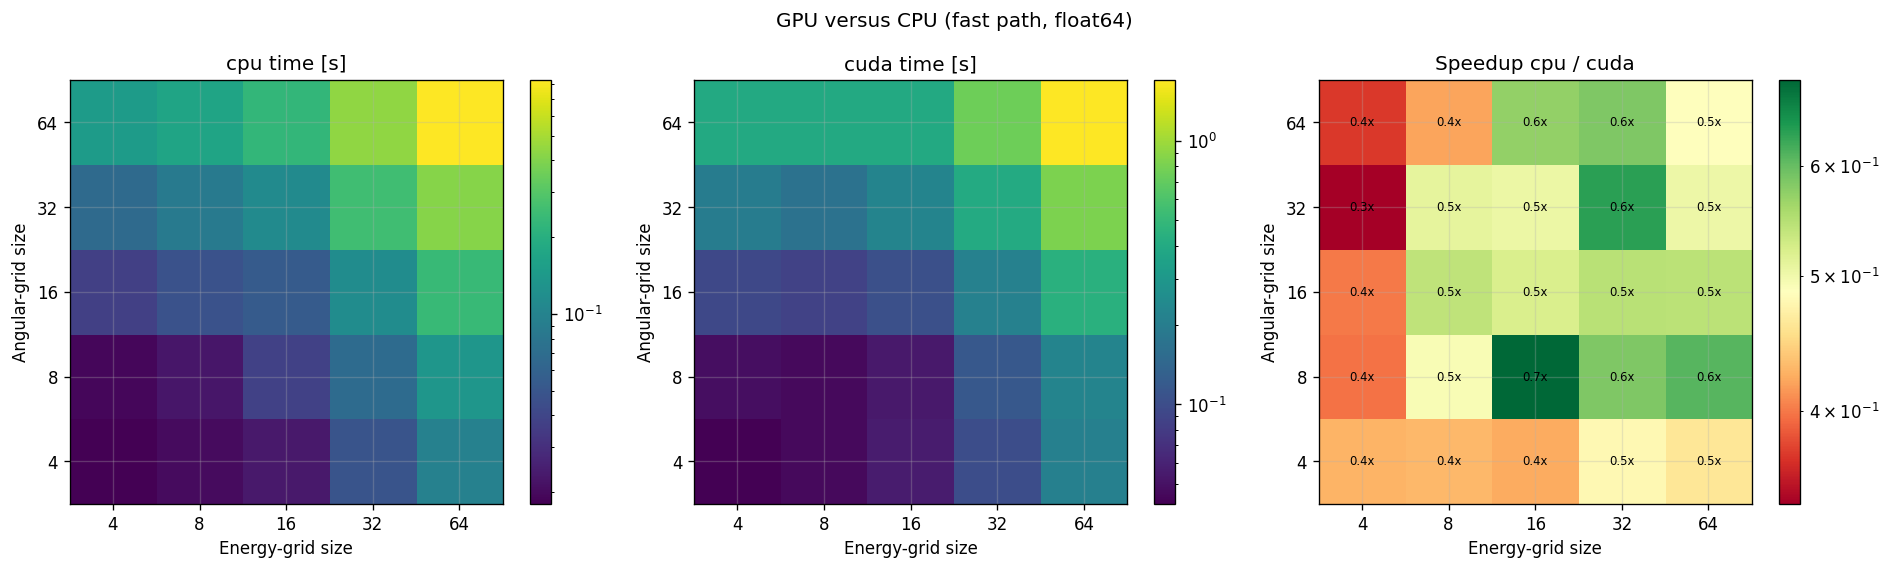

v:\output\benchmark\benchmark5_fig1_device_scaling.png


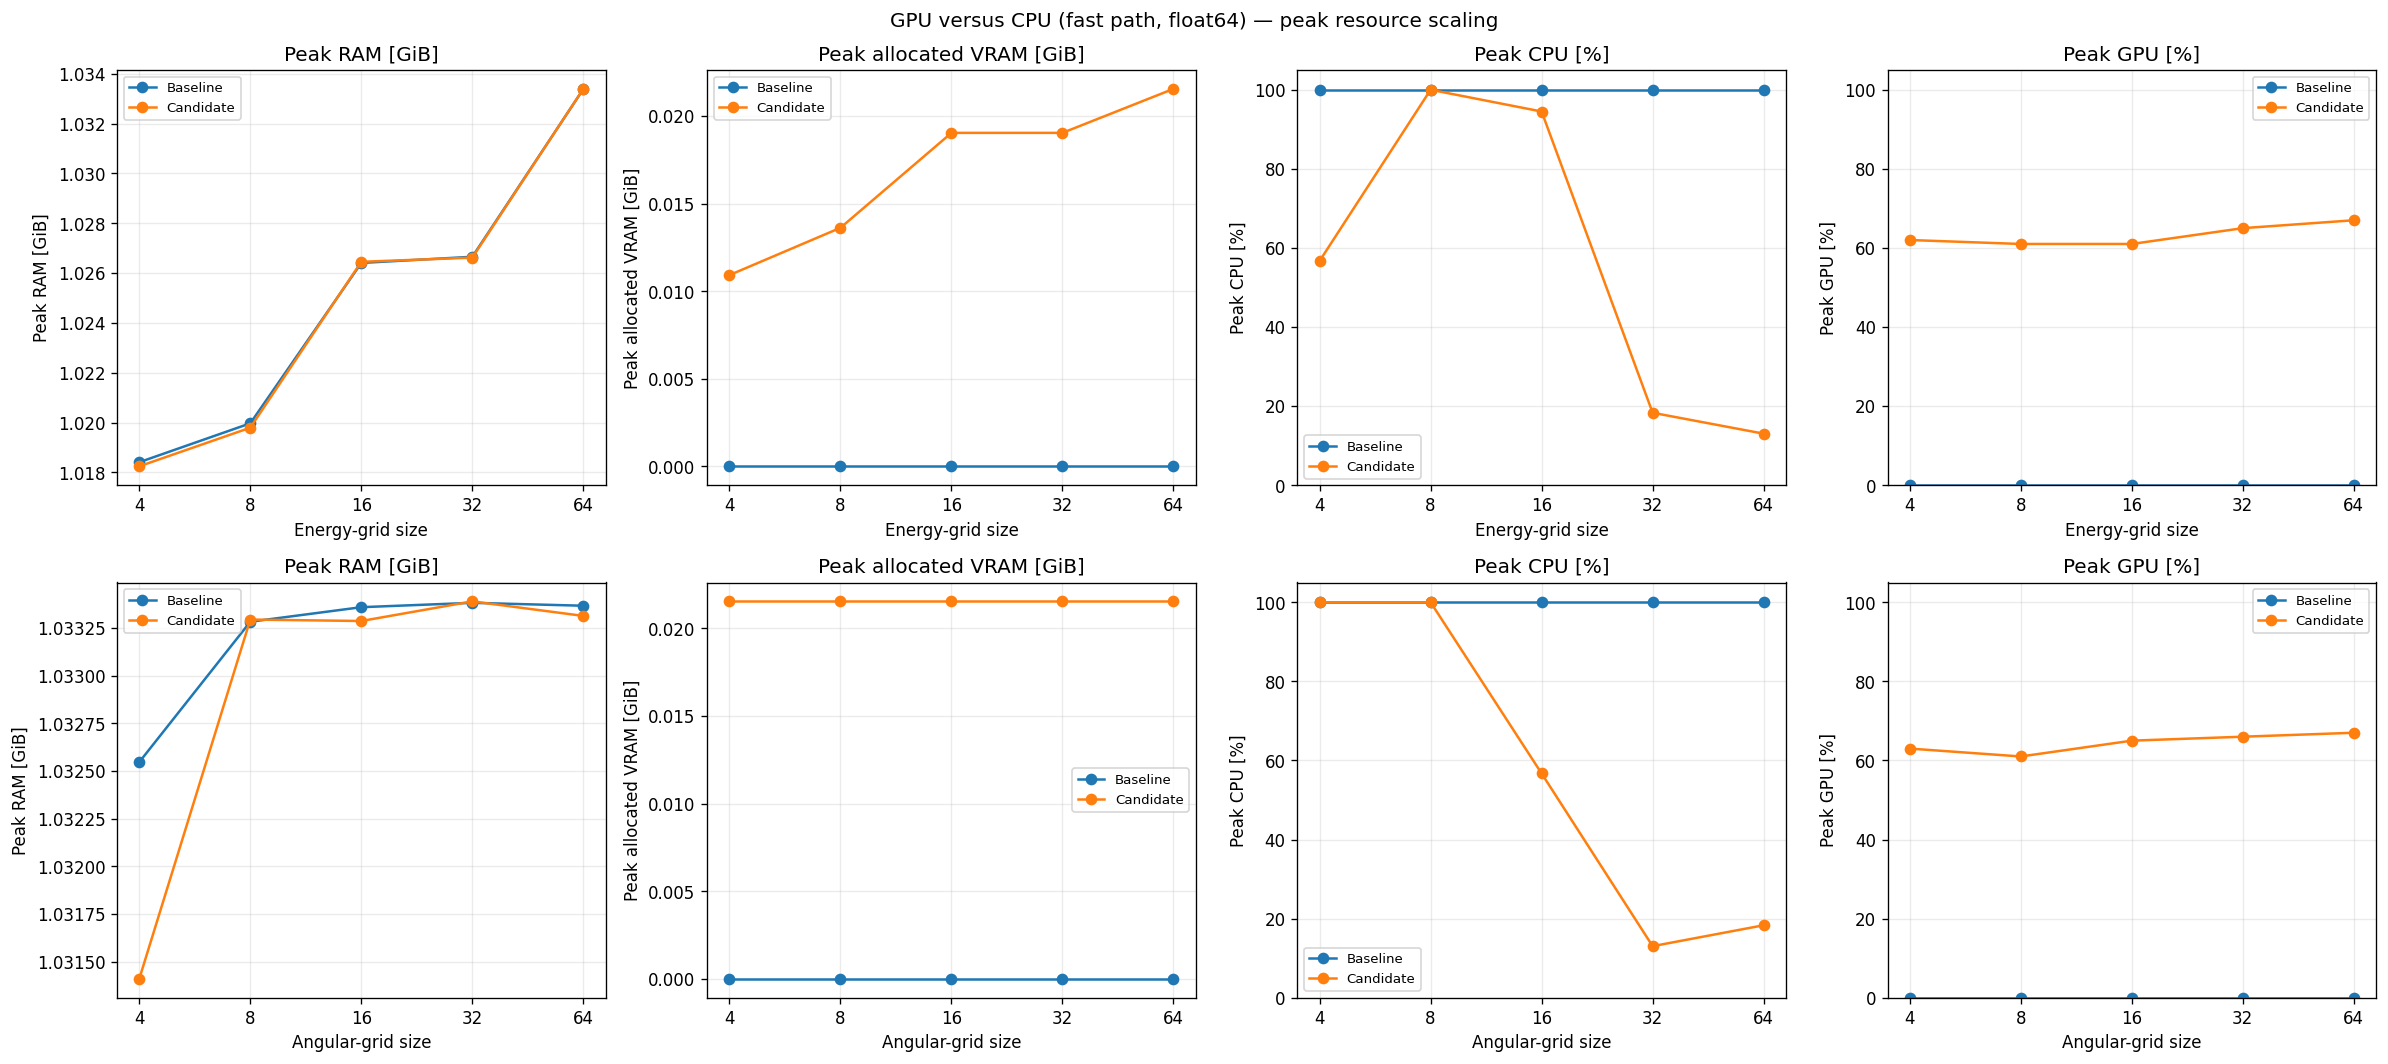

v:\output\benchmark\benchmark5_fig1_device_resource_scaling.png


In [5]:
if not CUDA_AVAILABLE:
    print('No CUDA device — skipping the GPU/CPU benchmark (Section 3).')
    device_df = None
else:
    device_df = benchmark_variant_grid(
        'GPU versus CPU (fast path, float64)', 'cpu', 'cuda',
        {'device': 'cpu', 'dtype': torch.float64, 'pipeline': 'fast'},
        {'device': 'cuda', 'dtype': torch.float64, 'pipeline': 'fast'},
        'benchmark5_fig1_device_scaling.png',
    )


## 4. Float32 versus Float64 Speedup

The same fast-path solar-to-Earth-detector chain is timed in `float64` and in `float32`, on the notebook's default device, for every grid-size pair.

**Expected results:**<br>
`float32` should be at least as fast as `float64` and typically faster on CUDA, where reduced-precision arithmetic and memory bandwidth both favour the smaller dtype; the effect may be smaller or absent on CPU.


Energy Grid Size: 4
.....
Energy Grid Size: 8
.....
Energy Grid Size: 16
.....
Energy Grid Size: 32
.....
Energy Grid Size: 64
.....


,case,baseline,candidate,n_energy,n_angle,baseline_s,candidate_s,speedup,baseline_std_s,candidate_std_s,baseline_ram_gb,baseline_cpu_percent,baseline_gpu_percent,baseline_vram_allocated_gb,baseline_vram_reserved_gb,candidate_ram_gb,candidate_cpu_percent,candidate_gpu_percent,candidate_vram_allocated_gb,candidate_vram_reserved_gb
0,Float64 versus float32 (fast path),float64,float32,4,4,0.058847,0.061401,0.958421,0.010200,0.011334,1.075394,12.6000,59.0,0.009925,0.021484,1.075699,12.6000,57.0,0.009240,0.021484
1,Float64 versus float32 (fast path),float64,float32,4,8,0.045195,0.046318,0.975753,0.009167,0.005214,1.075718,12.6000,62.0,0.011273,0.021484,1.075726,12.6000,34.0,0.009918,0.021484
2,Float64 versus float32 (fast path),float64,float32,4,16,0.093566,0.124903,0.749112,0.024440,0.002922,1.075729,12.6000,59.0,0.011273,0.021484,1.075729,12.6000,64.0,0.009918,0.021484
3,Float64 versus float32 (fast path),float64,float32,4,32,0.247885,0.229479,1.080208,0.008452,0.004473,1.075737,12.7375,67.0,0.011273,0.021484,1.075737,12.6000,65.0,0.009918,0.021484
4,Float64 versus float32 (fast path),float64,float32,4,64,0.412452,0.336470,1.225819,0.041072,0.031035,1.075737,12.6000,68.0,0.011273,0.021484,1.075737,12.6000,64.0,0.009918,0.021484
5,Float64 versus float32 (fast path),float64,float32,8,4,0.068679,0.066937,1.026029,0.001943,0.003040,1.075737,12.6000,61.0,0.011273,0.023438,1.075737,13.0250,61.0,0.009918,0.021484
6,Float64 versus float32 (fast path),float64,float32,8,8,0.075428,0.069181,1.090302,0.002606,0.009558,1.075737,13.0250,62.0,0.013971,0.023438,1.075737,12.6000,61.0,0.011266,0.021484
7,Float64 versus float32 (fast path),float64,float32,8,16,0.149154,0.128546,1.160309,0.003698,0.005189,1.075737,12.6000,68.0,0.013971,0.023438,1.075737,12.6000,61.0,0.011266,0.021484
8,Float64 versus float32 (fast path),float64,float32,8,32,0.288322,0.264575,1.089755,0.029180,0.005707,1.075737,12.6000,71.0,0.013971,0.023438,1.075741,13.0250,68.0,0.011266,0.021484
9,Float64 versus float32 (fast path),float64,float32,8,64,0.548665,0.332555,1.649847,0.005480,0.006873,1.075741,12.6000,71.0,0.013971,0.023438,1.075741,12.6000,49.0,0.011266,0.021484


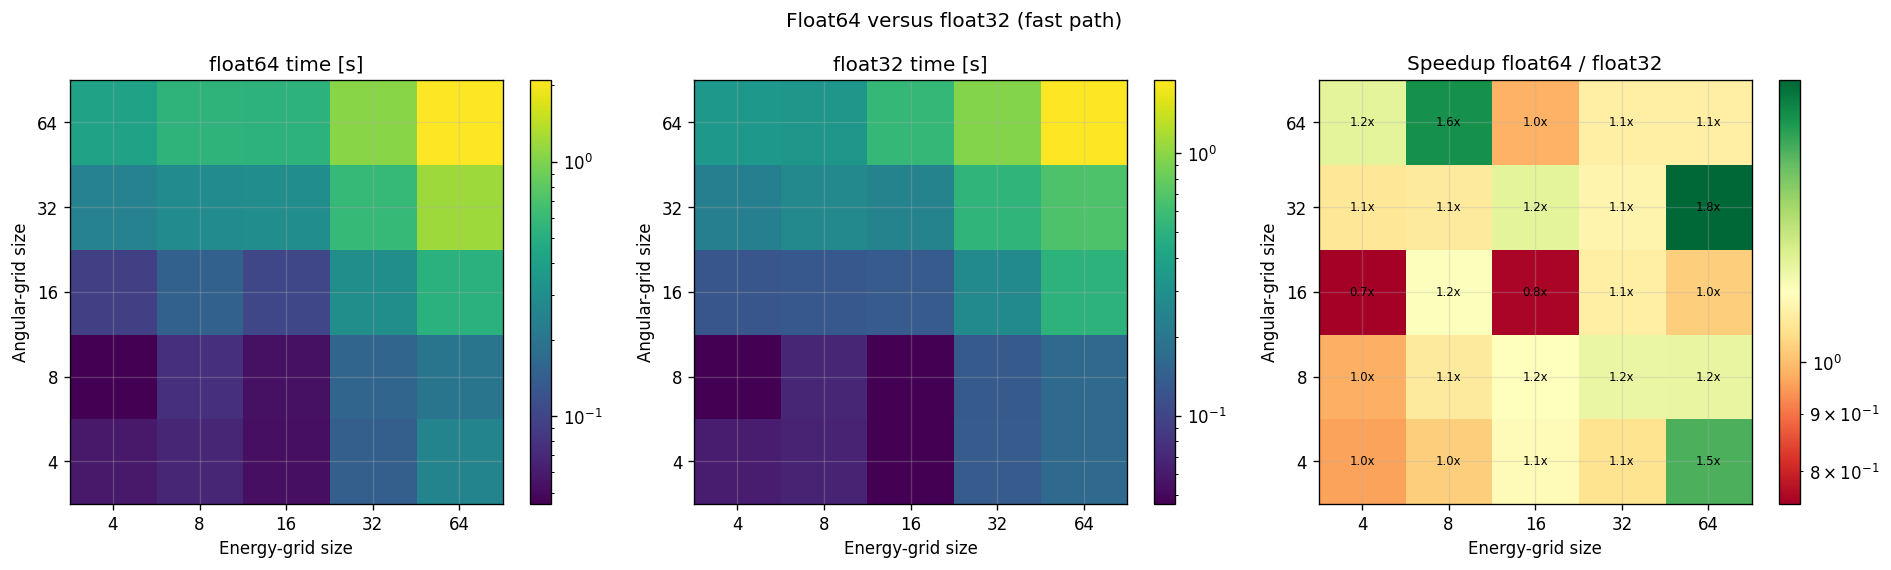

v:\output\benchmark\benchmark5_fig2_precision_scaling.png


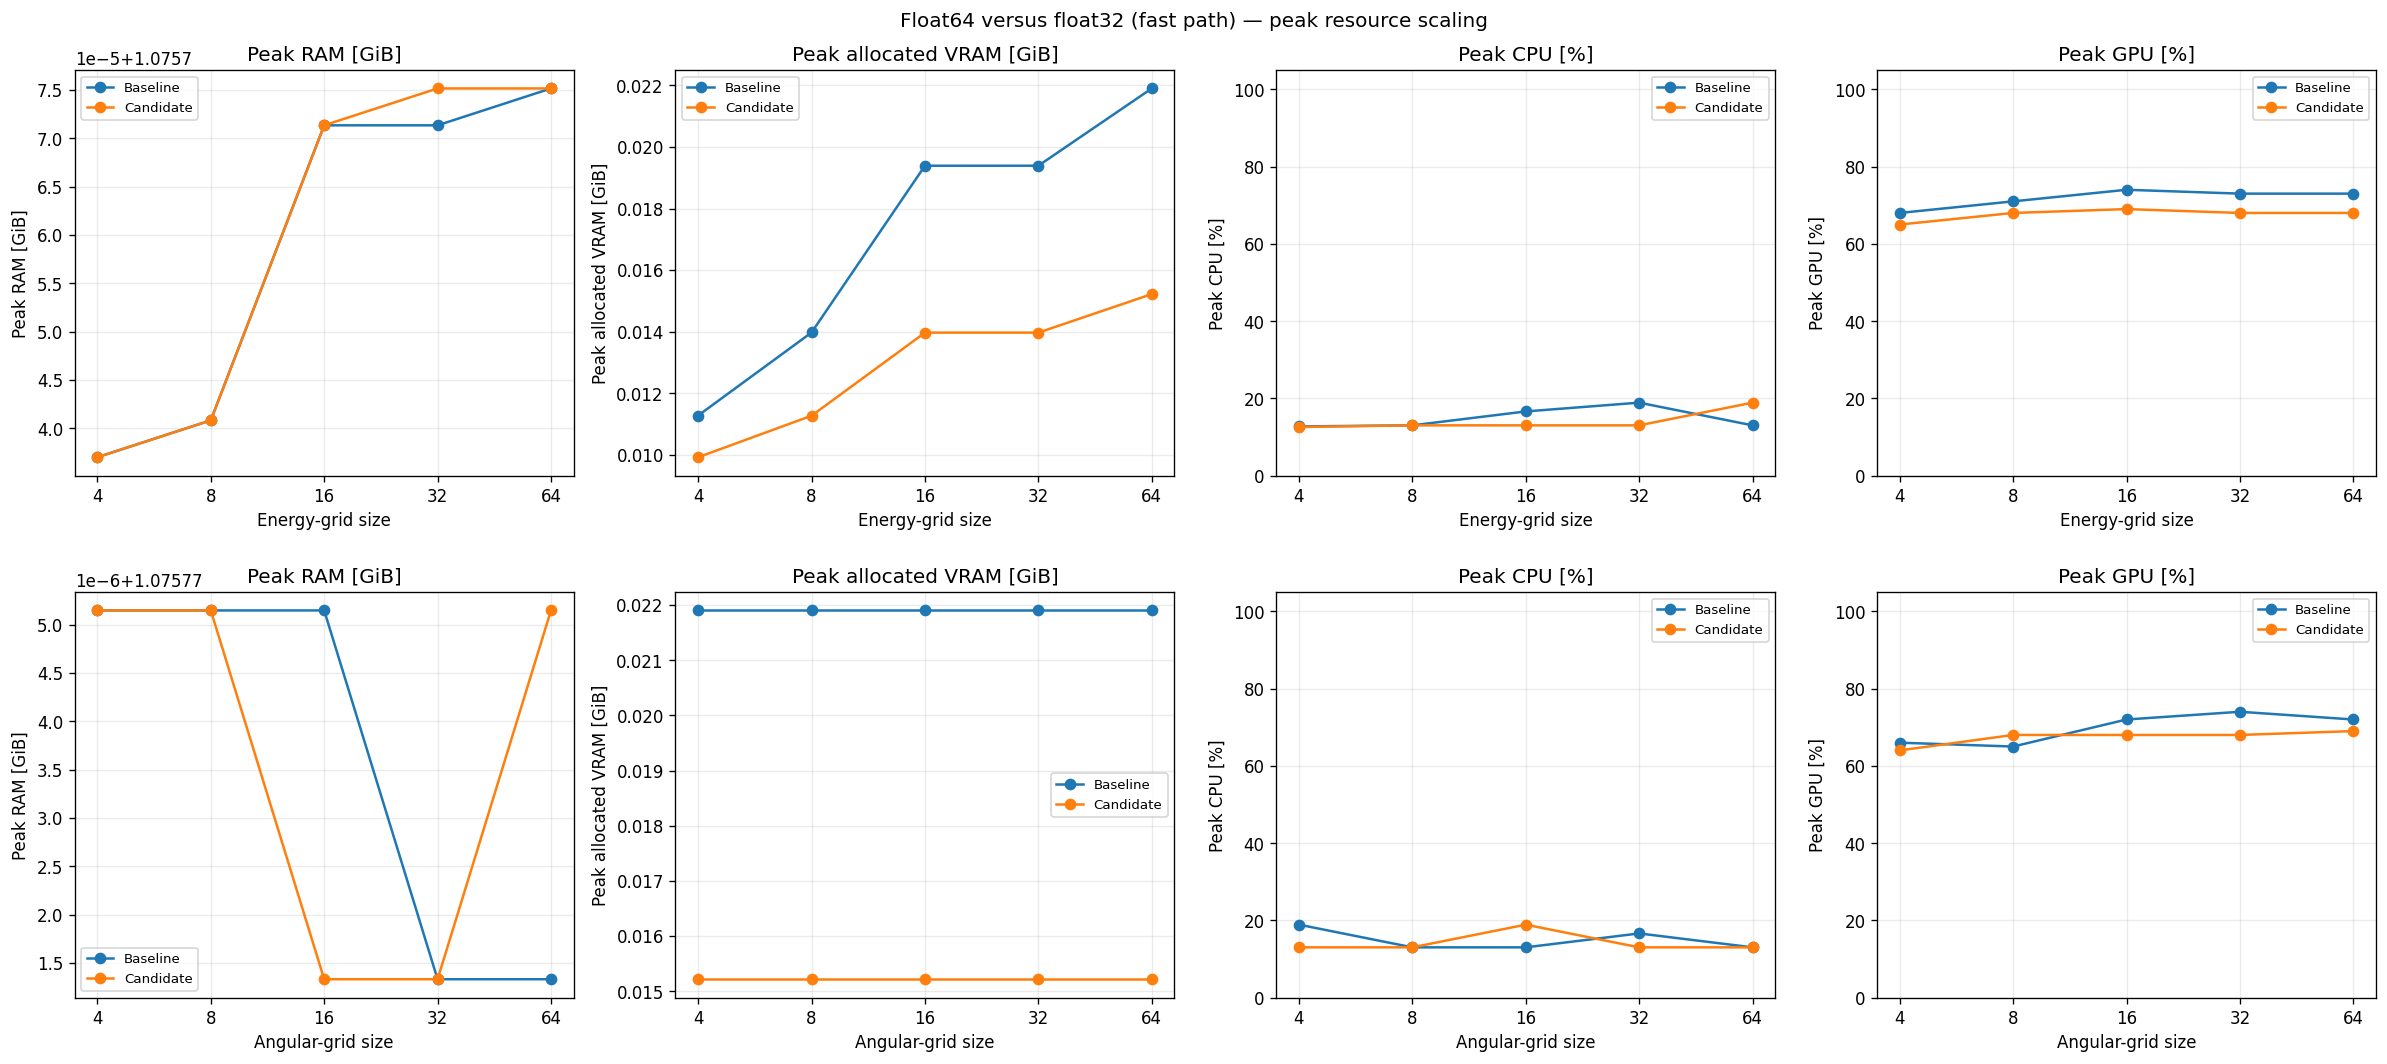

v:\output\benchmark\benchmark5_fig2_precision_resource_scaling.png


In [6]:
precision_df = benchmark_variant_grid(
    'Float64 versus float32 (fast path)', 'float64', 'float32',
    {'device': context.device, 'dtype': torch.float64, 'pipeline': 'fast'},
    {'device': context.device, 'dtype': torch.float32, 'pipeline': 'fast'},
    'benchmark5_fig2_precision_scaling.png',
)


## 5. Adiabatic/Perturbative versus Numerical Speedup

The same solar-to-Earth-detector chain is timed twice on the notebook's default device and `float64`: once using the fully numerical solar (`numerical`) and Earth (`numerical`, 400 steps) methods, and once using the fast adiabatic (`adiabatic_approximated`) solar method and the reunitarized perturbative (`analytical`) Earth method. Unlike `benchmark1_perturbative_vs_numerical.ipynb`'s Section 4, which precomputes the solar mass weights once and times only the Earth stage, both the solar and Earth stages are inside the timed region here, since the choice of solar method is itself part of the compared pipeline.

**Expected results:**<br>
the fast path should be substantially faster than the fully numerical path, combining the solar-surface saving (closed-form adiabatic angles versus coherent radial propagation) with the Earth saving already characterised in `benchmark1_perturbative_vs_numerical.ipynb`.


Energy Grid Size: 4
.....
Energy Grid Size: 8
.....
Energy Grid Size: 16
.....
Energy Grid Size: 32
.....
Energy Grid Size: 64
.....


,case,baseline,candidate,n_energy,n_angle,baseline_s,candidate_s,speedup,baseline_std_s,candidate_std_s,baseline_ram_gb,baseline_cpu_percent,baseline_gpu_percent,baseline_vram_allocated_gb,baseline_vram_reserved_gb,candidate_ram_gb,candidate_cpu_percent,candidate_gpu_percent,candidate_vram_allocated_gb,candidate_vram_reserved_gb
0,Numerical versus fast adiabatic/perturbative path,numerical,fast,4,4,0.258740,0.047372,5.461860,0.006628,0.002900,1.166447,12.6000,61.0,0.022747,0.042969,1.162434,12.6000,40.0,0.009925,0.021484
1,Numerical versus fast adiabatic/perturbative path,numerical,fast,4,8,0.333361,0.046304,7.199415,0.002821,0.002221,1.162437,12.6000,61.0,0.022747,0.042969,1.162441,13.0250,40.0,0.011273,0.021484
2,Numerical versus fast adiabatic/perturbative path,numerical,fast,4,16,0.478663,0.089112,5.371499,0.009118,0.002834,1.162441,13.0250,64.0,0.022747,0.042969,1.162441,12.6000,41.0,0.011273,0.021484
3,Numerical versus fast adiabatic/perturbative path,numerical,fast,4,32,0.988403,0.261782,3.775675,0.057311,0.007122,1.162449,12.6000,78.0,0.022747,0.042969,1.162449,12.6000,69.0,0.011273,0.021484
4,Numerical versus fast adiabatic/perturbative path,numerical,fast,4,64,1.772647,0.492796,3.597119,0.052206,0.017065,1.162460,13.0250,77.0,0.022747,0.042969,1.162460,13.0250,69.0,0.011273,0.021484
5,Numerical versus fast adiabatic/perturbative path,numerical,fast,8,4,0.326812,0.067345,4.852835,0.007794,0.004671,1.150402,12.6000,80.0,0.036873,0.048828,1.150406,12.6000,66.0,0.011273,0.023438
6,Numerical versus fast adiabatic/perturbative path,numerical,fast,8,8,0.452754,0.077497,5.842209,0.018615,0.002103,1.150406,12.6000,82.0,0.036873,0.048828,1.150406,12.6000,65.0,0.013971,0.023438
7,Numerical versus fast adiabatic/perturbative path,numerical,fast,8,16,0.658945,0.134143,4.912256,0.011728,0.002677,1.150406,13.0250,78.0,0.036873,0.048828,1.150406,12.6000,66.0,0.013971,0.023438
8,Numerical versus fast adiabatic/perturbative path,numerical,fast,8,32,1.138331,0.251528,4.525669,0.004661,0.001700,1.150410,12.6000,81.0,0.036873,0.048828,1.150410,13.0250,70.0,0.013971,0.023438
9,Numerical versus fast adiabatic/perturbative path,numerical,fast,8,64,2.031123,0.517195,3.927189,0.018734,0.005597,1.150410,12.7375,84.0,0.036873,0.048828,1.150410,13.0250,69.0,0.013971,0.023438


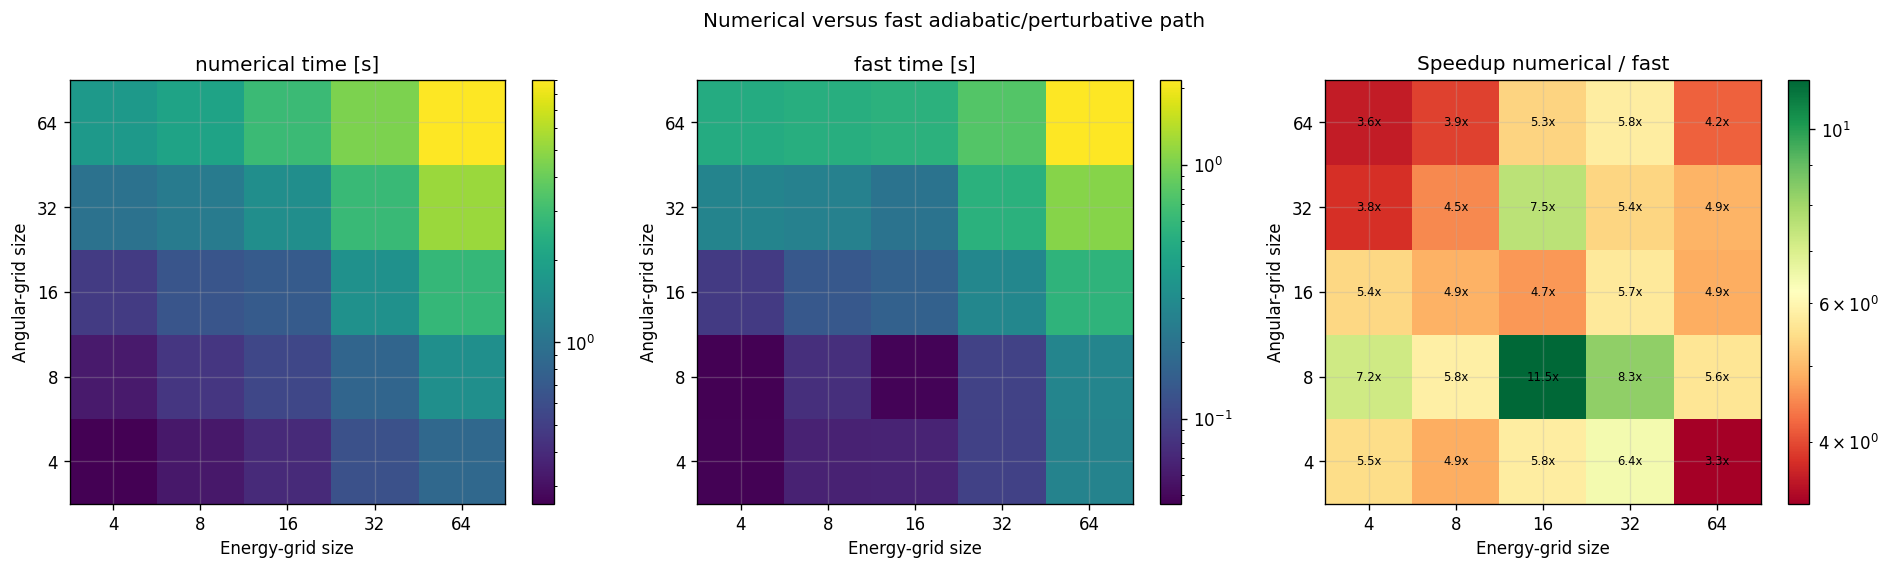

v:\output\benchmark\benchmark5_fig3_method_scaling.png


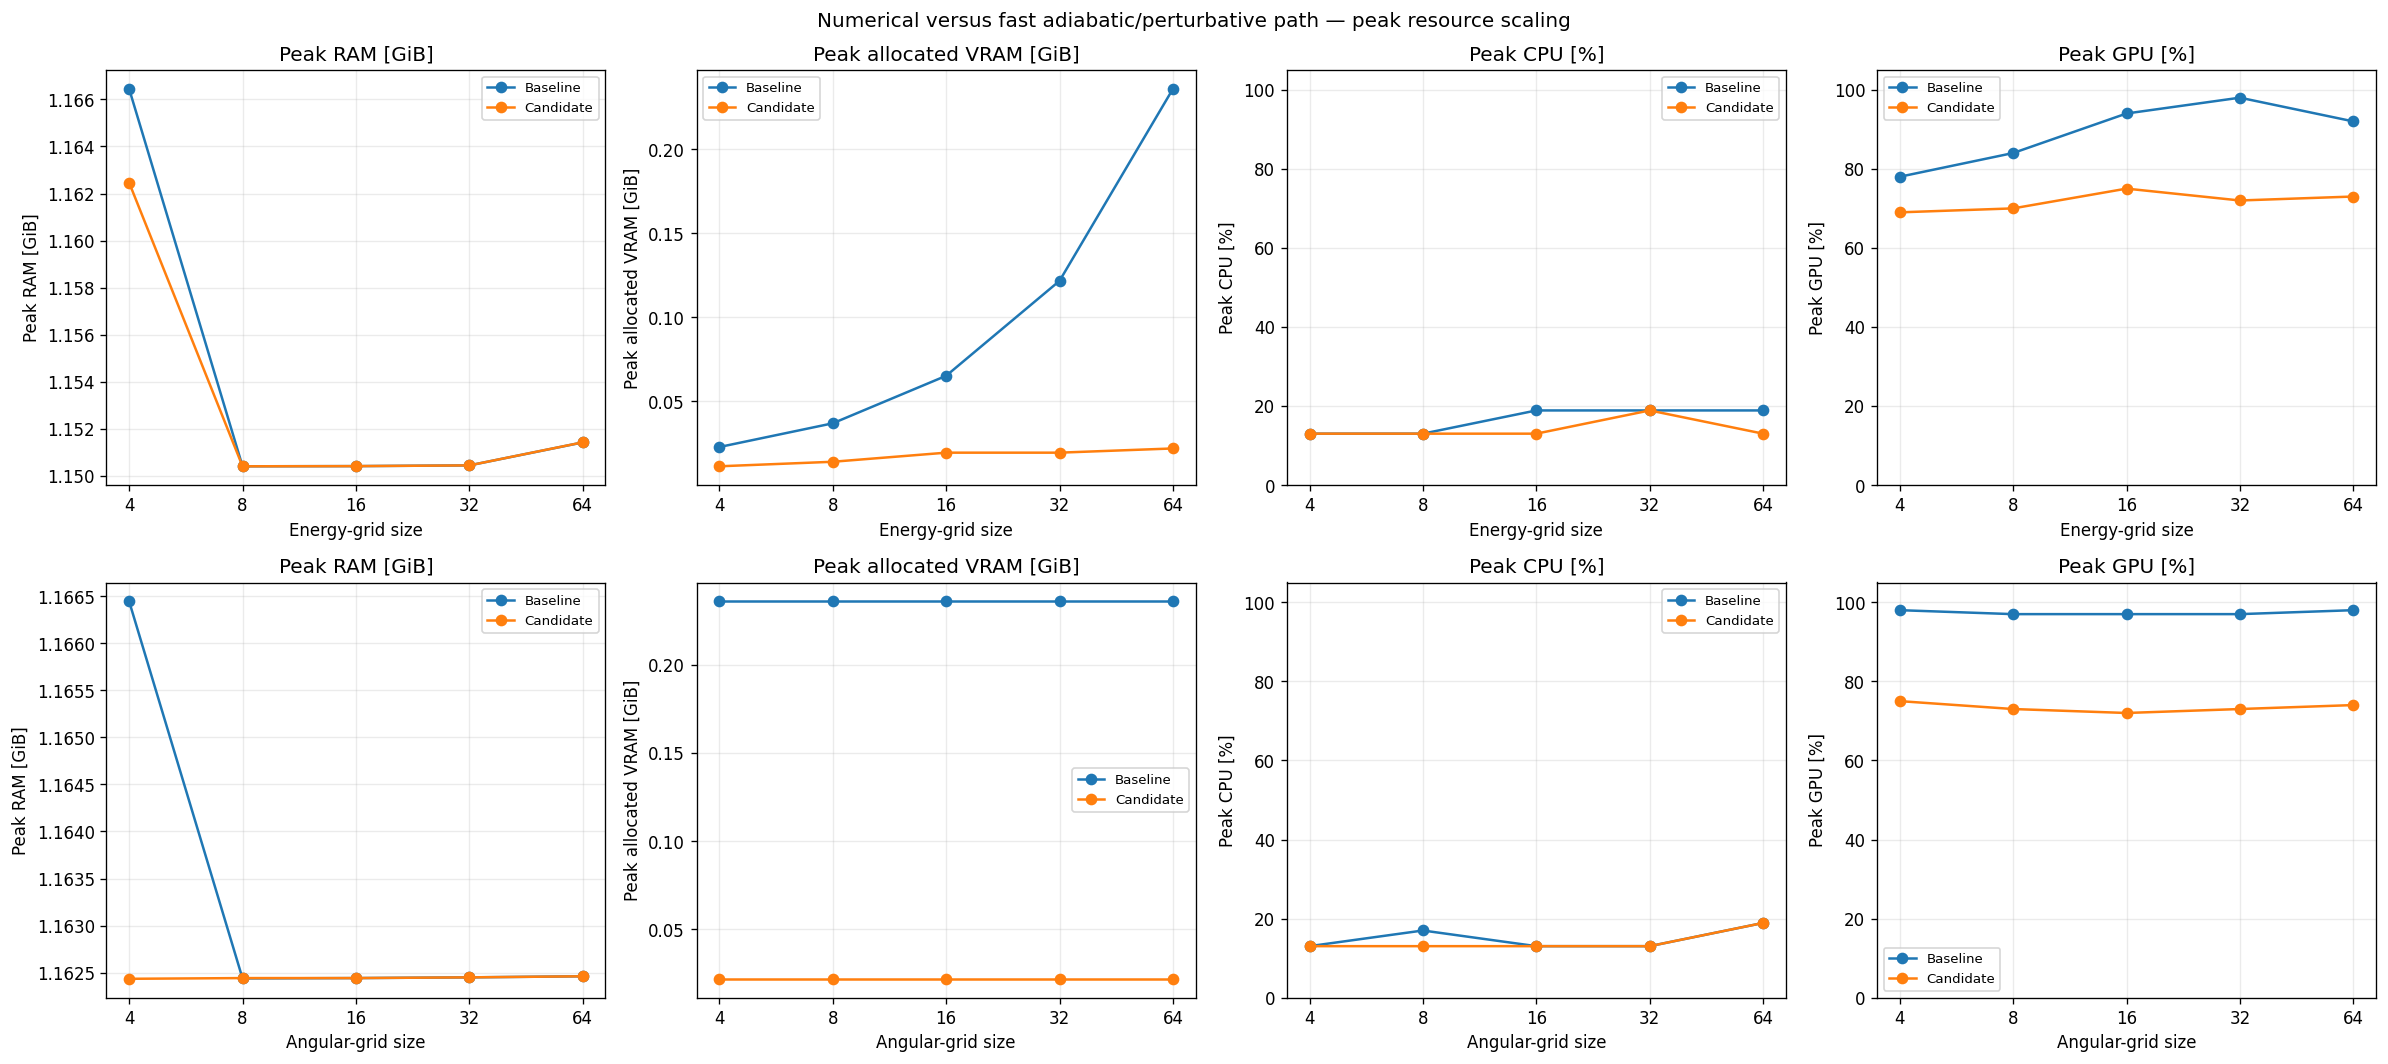

v:\output\benchmark\benchmark5_fig3_method_resource_scaling.png


In [7]:
method_df = benchmark_variant_grid(
    'Numerical versus fast adiabatic/perturbative path', 'numerical', 'fast',
    {'device': context.device, 'dtype': torch.float64, 'pipeline': 'numerical'},
    {'device': context.device, 'dtype': torch.float64, 'pipeline': 'fast'},
    'benchmark5_fig3_method_scaling.png',
)


## 6. Resource Consumption

The plots compare the maximum process RAM, allocated/reserved VRAM and process CPU/GPU utilization observed in each section. Peaks are taken over every grid size and timed repetition, so they represent the most demanding measured configuration rather than an average. CPU utilization is normalized by `CPU_THREADS`, so 100% represents full use of the configured CPU budget.

**Expected results:**<br>
process RAM remains below `MAX_RAM_GB`; CUDA memory remains below the configured allocator fraction. The numerical-method branch of Section 5 should generally require more memory than the fast-path branch used as the baseline/candidate in Sections 3-4.


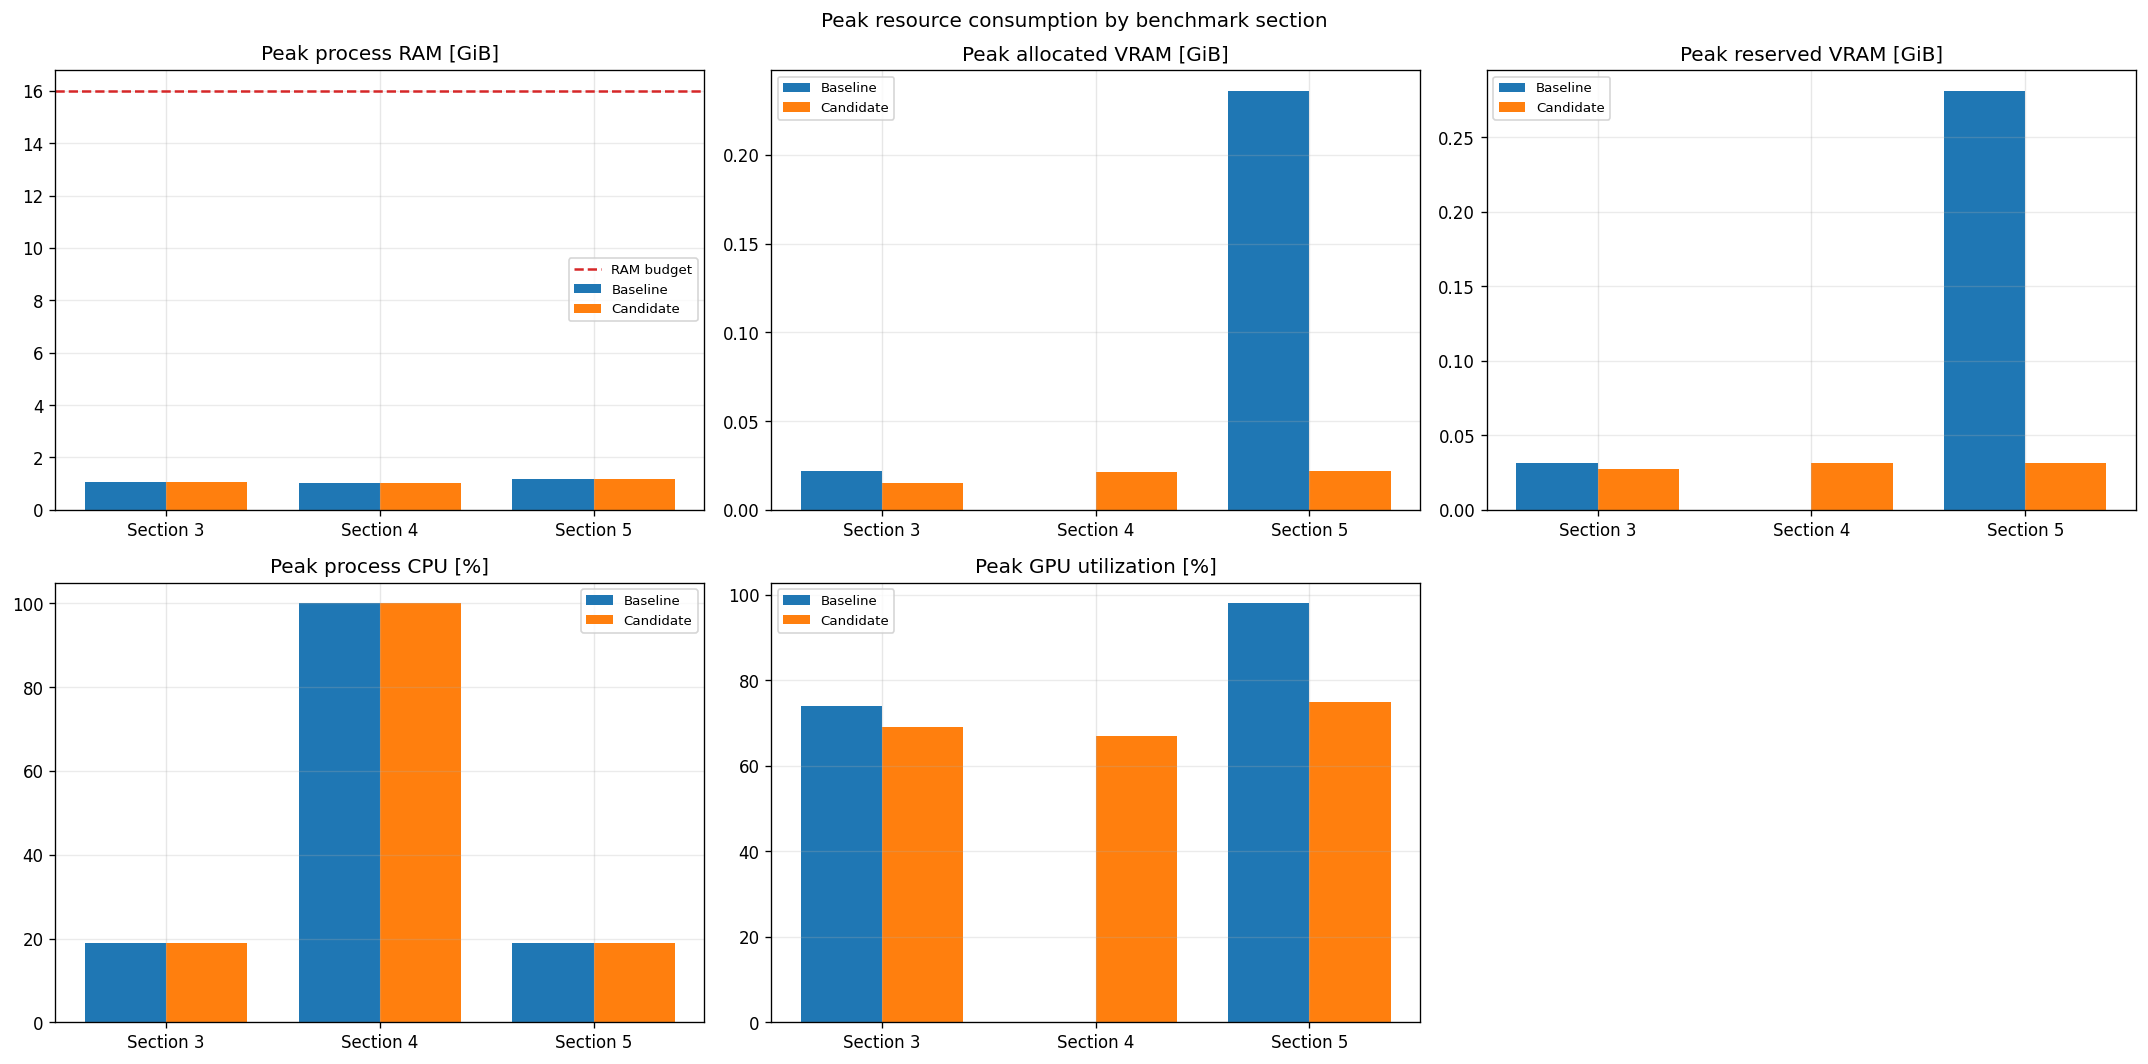

v:\output\benchmark\benchmark5_fig4_resource_consumption.png


ram_gb  \
case                                              branch                
Float64 versus float32 (fast path)                baseline   1.075775   
                                                  candidate  1.075775   
GPU versus CPU (fast path, float64)               baseline   1.033382   
                                                  candidate  1.033390   
Numerical versus fast adiabatic/perturbative path baseline   1.166447   
                                                  candidate  1.162460   

                                                             vram_allocated_gb  \
case                                              branch                         
Float64 versus float32 (fast path)                baseline            0.021902   
                                                  candidate           0.015218   
GPU versus CPU (fast path, float64)               baseline            0.000000   
                                                  candidate           0.021544   
Numerical versus fast adiabatic/perturbative path baseline            0.236091   
                                                  candidate           0.021902   

                                                             vram_reserved_gb  \
case                                              branch                        
Float64 versus float32 (fast path)                baseline           0.031250   
                                                  candidate          0.027344   
GPU versus CPU (fast path, float64)               baseline           0.000000   
                                                  candidate          0.031250   
Numerical versus fast adiabatic/perturbative path baseline           0.281250   
                                                  candidate          0.031250   

                                                             cpu_percent  \
case                                              branch                   
Float64 versus float32 (fast path)                baseline          18.9   
                                                  candidate         18.9   
GPU versus CPU (fast path, float64)               baseline         100.0   
                                                  candidate        100.0   
Numerical versus fast adiabatic/perturbative path baseline          18.9   
                                                  candidate         18.9   

                                                             gpu_percent  
case                                              branch                  
Float64 versus float32 (fast path)                baseline          74.0  
                                                  candidate         69.0  
GPU versus CPU (fast path, float64)               baseline           0.0  
                                                  candidate         67.0  
Numerical versus fast adiabatic/perturbative path baseline          98.0  
                                                  candidate         75.0

In [8]:
resource_results = pd.concat(benchmark_tables, ignore_index=True)
resource_columns = ['ram_gb', 'vram_allocated_gb', 'vram_reserved_gb', 'cpu_percent', 'gpu_percent']
resource_summary = pd.DataFrame([{'case': case, 'branch': branch, **{metric: group[f'{branch}_{metric}'].max() for metric in resource_columns}} for case, group in resource_results.groupby('case') for branch in ('baseline', 'candidate')])
resource_summary.to_csv(OUTPUT_DIR / 'benchmark5_resource_summary.csv', index=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
x = np.arange(resource_summary['case'].nunique()); width = 0.38
cases = resource_summary['case'].drop_duplicates().tolist()
for ax, metric, title in zip(axes.flat, resource_columns, ('Peak process RAM [GiB]', 'Peak allocated VRAM [GiB]', 'Peak reserved VRAM [GiB]', 'Peak process CPU [%]', 'Peak GPU utilization [%]')):
    for offset, branch in zip((-width/2, width/2), ('baseline', 'candidate')):
        values = resource_summary[resource_summary.branch == branch].set_index('case').loc[cases, metric]
        ax.bar(x + offset, values, width, label=branch.capitalize())
    ax.set_xticks(x, [f'Section {index + 3}' for index in range(len(cases))]); ax.set_title(title); ax.grid(axis='y', alpha=.25)
    if metric == 'ram_gb': ax.axhline(MAX_RAM_GB, color='tab:red', ls='--', label='RAM budget')
    ax.legend(fontsize=8)
axes.flat[-1].axis('off')
fig.suptitle('Peak resource consumption by benchmark section'); fig.tight_layout(); save_and_show('benchmark5_fig4_resource_consumption.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)
display(resource_summary.set_index(['case', 'branch']))


## 7. Summary
The combined table contains one comparison for every \((N_E,N_\eta)\) pair and section. The extremes table below reports, for each of Sections 3-5, the smallest and largest \((N_E,N_\eta)\) grid-size combination actually used and the speedup obtained there, giving a compact before/after view of how each runtime choice scales from the cheapest to the most demanding configuration benchmarked. Raw results are exported to `benchmark5_context.csv`.

**Results Interpretation:**<br>
- All times and speedups are finite and positive.
- Speedup generally grows from the smallest to the largest grid for the device and precision axes, once fixed dispatch overhead is amortised.
- The method axis (Section 5) is expected to favour the fast path at every grid size.


,case,baseline,candidate,n_energy,n_angle,baseline_s,candidate_s,speedup,baseline_std_s,candidate_std_s,baseline_ram_gb,baseline_cpu_percent,baseline_gpu_percent,baseline_vram_allocated_gb,baseline_vram_reserved_gb,candidate_ram_gb,candidate_cpu_percent,candidate_gpu_percent,candidate_vram_allocated_gb,candidate_vram_reserved_gb
0,"GPU versus CPU (fast path, float64)",cpu,cuda,4,4,0.017987,0.042017,0.428088,0.003599,0.000872,0.804764,100.0000,0.0,0.000000,0.00000,1.017639,12.600,25.0,0.009566,0.021484
1,"GPU versus CPU (fast path, float64)",cpu,cuda,4,8,0.019108,0.048101,0.397248,0.001692,0.001195,1.018219,0.0000,0.0,0.000000,0.00000,1.018246,56.700,31.0,0.010915,0.021484
2,"GPU versus CPU (fast path, float64)",cpu,cuda,4,16,0.037349,0.093387,0.399938,0.001162,0.001244,1.018276,100.0000,0.0,0.000000,0.00000,1.017849,13.025,46.0,0.010915,0.021484
3,"GPU versus CPU (fast path, float64)",cpu,cuda,4,32,0.067824,0.197695,0.343074,0.004934,0.006383,1.017918,100.0000,0.0,0.000000,0.00000,1.017944,13.025,56.0,0.010915,0.021484
4,"GPU versus CPU (fast path, float64)",cpu,cuda,4,64,0.147901,0.397928,0.371679,0.002955,0.008881,1.018410,100.0000,0.0,0.000000,0.00000,1.017960,12.600,62.0,0.010915,0.021484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,Numerical versus fast adiabatic/perturbative path,numerical,fast,64,4,0.860540,0.257760,3.338538,0.031435,0.006436,1.151424,12.6000,88.0,0.236091,0.28125,1.151417,12.600,70.0,0.021902,0.031250
71,Numerical versus fast adiabatic/perturbative path,numerical,fast,64,8,1.506194,0.267549,5.629598,0.029988,0.019918,1.151417,16.9875,91.0,0.236091,0.28125,1.151417,13.025,73.0,0.021902,0.031250
72,Numerical versus fast adiabatic/perturbative path,numerical,fast,64,16,2.743730,0.564815,4.857750,0.025985,0.004926,1.151417,13.0250,84.0,0.236091,0.28125,1.151417,13.025,72.0,0.021902,0.031250
73,Numerical versus fast adiabatic/perturbative path,numerical,fast,64,32,5.308880,1.075539,4.936016,0.169062,0.037893,1.151417,13.0250,92.0,0.236091,0.28125,1.151417,13.025,73.0,0.021902,0.031250


,section,baseline,candidate,grid,n_energy,n_angle,baseline_s,candidate_s,speedup
0,"GPU versus CPU (fast path, float64)",cpu,cuda,smallest grid,4,4,0.017987,0.042017,0.428088
1,"GPU versus CPU (fast path, float64)",cpu,cuda,largest grid,64,64,0.827935,1.700315,0.486930
2,Float64 versus float32 (fast path),float64,float32,smallest grid,4,4,0.058847,0.061401,0.958421
3,Float64 versus float32 (fast path),float64,float32,largest grid,64,64,2.099970,1.899510,1.105533
4,Numerical versus fast adiabatic/perturbative path,numerical,fast,smallest grid,4,4,0.258740,0.047372,5.461860
5,Numerical versus fast adiabatic/perturbative path,numerical,fast,largest grid,64,64,9.001899,2.155076,4.177069


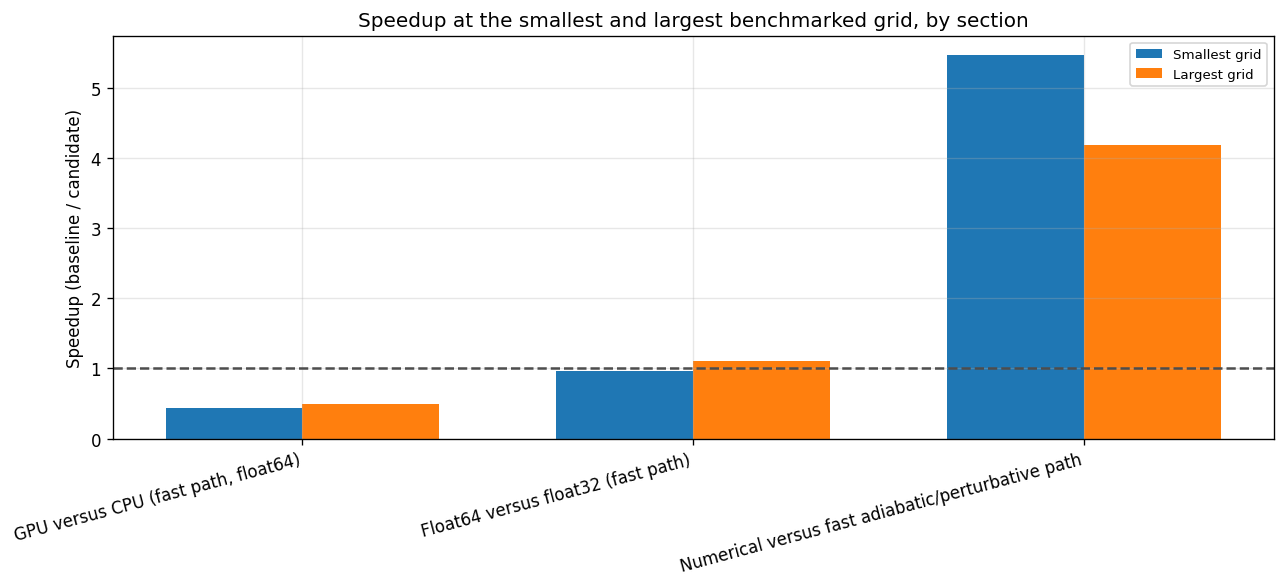

v:\output\benchmark\benchmark5_fig5_summary_extremes.png
All benchmarked sections completed successfully.


In [9]:
results = pd.concat(benchmark_tables, ignore_index=True)
display(results)
results.to_csv(OUTPUT_DIR / 'benchmark5_context.csv', index=False)
numeric_results = results.select_dtypes(include=np.number)
assert np.isfinite(numeric_results.to_numpy()).all() and (results[['baseline_s', 'candidate_s', 'speedup']] > 0).all().all()
assert (results[['baseline_ram_gb', 'candidate_ram_gb']] <= MAX_RAM_GB).all().all()

smallest_ne, largest_ne = min(ENERGY_GRID_SIZES), max(ENERGY_GRID_SIZES)
smallest_na, largest_na = min(ANGLE_GRID_SIZES), max(ANGLE_GRID_SIZES)
extremes_rows = []
for case, group in results.groupby('case', sort=False):
    baseline_label, candidate_label = group['baseline'].iloc[0], group['candidate'].iloc[0]
    for label, ne, na in (('smallest grid', smallest_ne, smallest_na), ('largest grid', largest_ne, largest_na)):
        row = group[(group.n_energy == ne) & (group.n_angle == na)]
        if len(row):
            row = row.iloc[0]
            extremes_rows.append({'section': case, 'baseline': baseline_label, 'candidate': candidate_label, 'grid': label, 'n_energy': ne, 'n_angle': na, 'baseline_s': row['baseline_s'], 'candidate_s': row['candidate_s'], 'speedup': row['speedup']})
extremes_table = pd.DataFrame(extremes_rows)
display(extremes_table)
extremes_table.to_csv(OUTPUT_DIR / 'benchmark5_grid_extremes_speedup.csv', index=False)

fig, ax = plt.subplots(figsize=(11, 5.0))
x = np.arange(extremes_table['section'].nunique()); width = 0.35
sections = extremes_table['section'].drop_duplicates().tolist()
for offset, grid_label, colour in zip((-width/2, width/2), ('smallest grid', 'largest grid'), ('C0', 'C1')):
    values = extremes_table[extremes_table.grid == grid_label].set_index('section').loc[sections, 'speedup']
    ax.bar(x + offset, values, width, label=grid_label.capitalize(), color=colour)
ax.axhline(1.0, color='0.3', ls='--')
ax.set_xticks(x, sections, rotation=15, ha='right'); ax.set_ylabel('Speedup (baseline / candidate)')
ax.set_title('Speedup at the smallest and largest benchmarked grid, by section'); ax.legend(fontsize=8)
fig.tight_layout(); save_and_show('benchmark5_fig5_summary_extremes.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)
print('All benchmarked sections completed successfully.')
